# CIC IoT 23 Data Processing

This notebook applies the preprocessing pipeline to the CIC IoT 23 dataset:
- binary target conversion
- one-hot encoding
- train/test split
- undersampling
- min-max scaling
- PCA

Then, we use UMAP to visualize both the data before and after preprocessing.


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# print(PROJECT_ROOT)

In [3]:
from preprocessing import (
    timed_preprocess_cic_iot23,
    plot_dimensionality_summary,
    plot_explained_variance,
    plot_pca_scatter,
    plot_umap,
    plot_umap_comparison,
)


In [4]:
prep = timed_preprocess_cic_iot23(
    "../data/Merged01.csv",
    n_components=4,
    vis_samples=1000,
    label_col="Label",
    benign_values=("benign",),
)

X_train = prep["X_train_pca"]
X_test = prep["X_test_pca"]
y_train = prep["y_train"]
y_test = prep["y_test"]

print("Full train:", X_train.shape)
print("Full test: ", X_test.shape)
print("Raw dimensions:", prep["original_dim"])
print("After one-hot encoding:", prep["encoded_dim"])
print("After PCA:", prep["final_dim"])
print("Explained variance kept:", prep["pca"].explained_variance_ratio_.sum())


Found inf/-inf or invalid numeric values.
CIC IoT 23 preprocessing time: 5.22s
Full train: (26524, 4)
Full test:  (142463, 4)
Raw dimensions: 39
After one-hot encoding: 39
After PCA: 4
Explained variance kept: 0.7817259


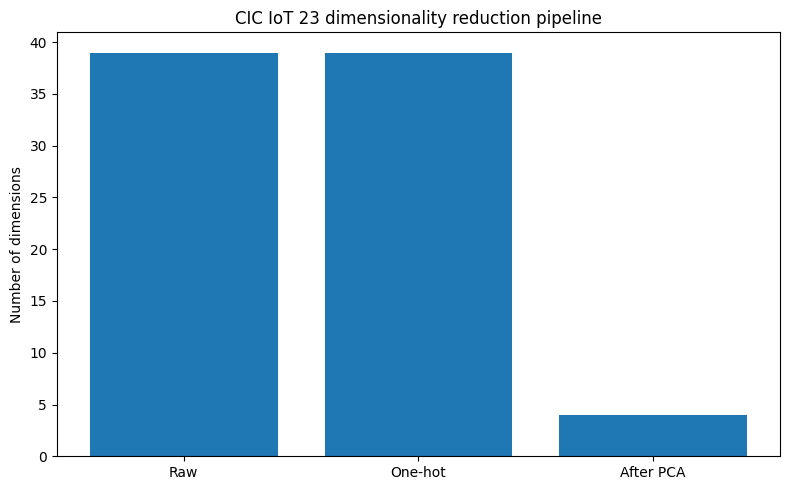

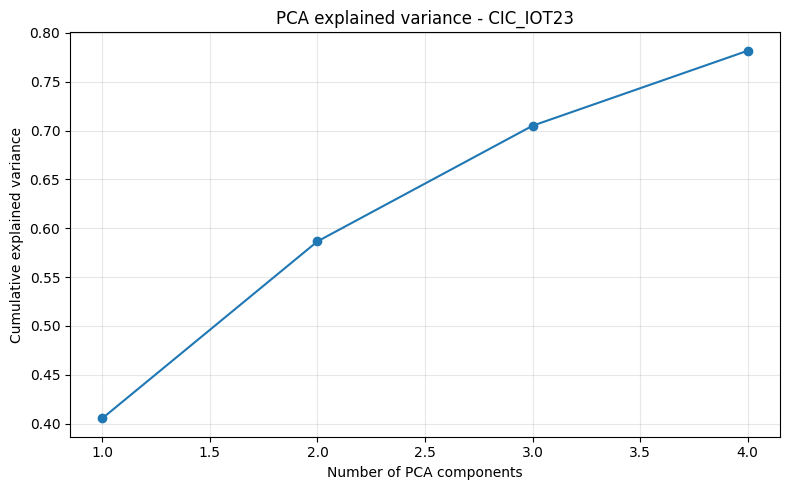

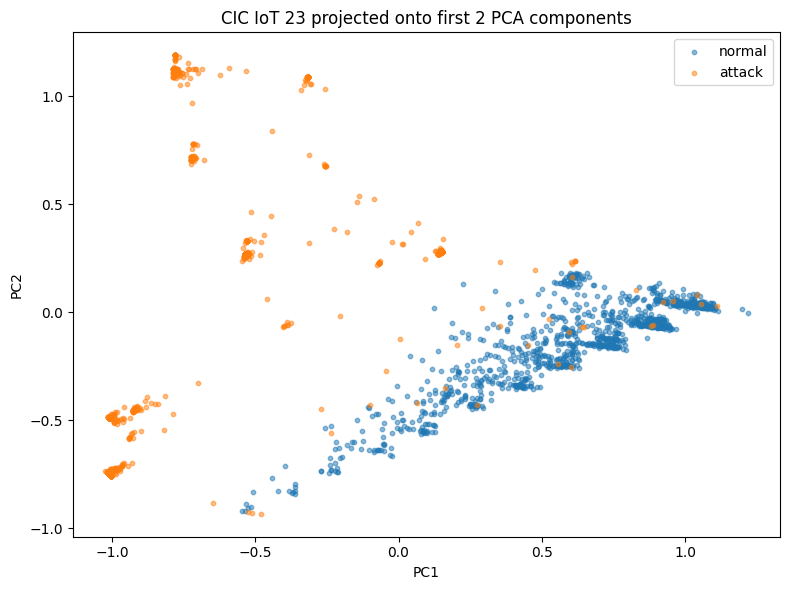

In [4]:
plot_dimensionality_summary(
    prep["original_dim"],
    prep["encoded_dim"],
    prep["final_dim"],
    title="CIC IoT 23 dimensionality reduction pipeline",
)

plot_explained_variance(prep["pca"], dataset="CIC_IOT23")
plot_pca_scatter(
    prep["X_train_pca"],
    prep["y_train"],
    title="CIC IoT 23 projected onto first 2 PCA components",
)


/home/senachioiu/AQA-QDL/AQA_QDL-main/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


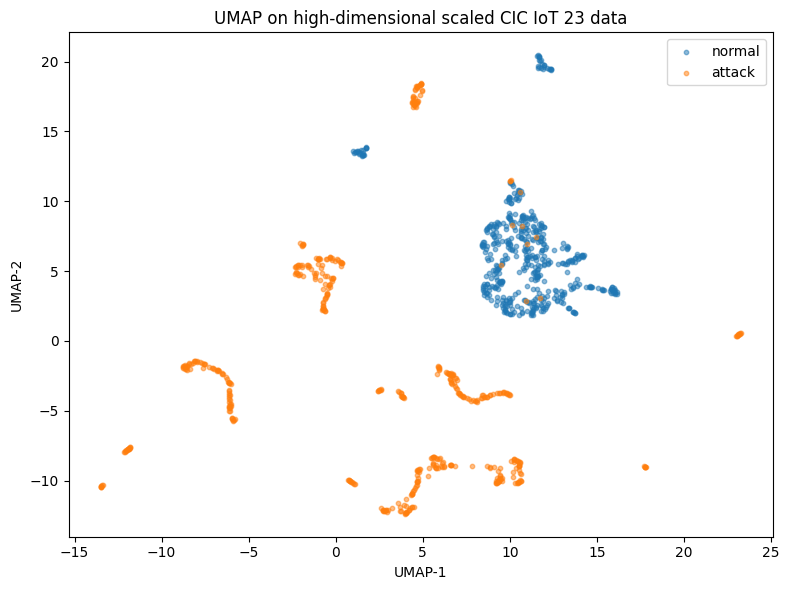

In [5]:
plot_umap(
    prep["X_vis_scaled"],
    prep["y_vis"],
    "UMAP on high-dimensional scaled CIC IoT 23 data"
)


/home/senachioiu/AQA-QDL/AQA_QDL-main/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


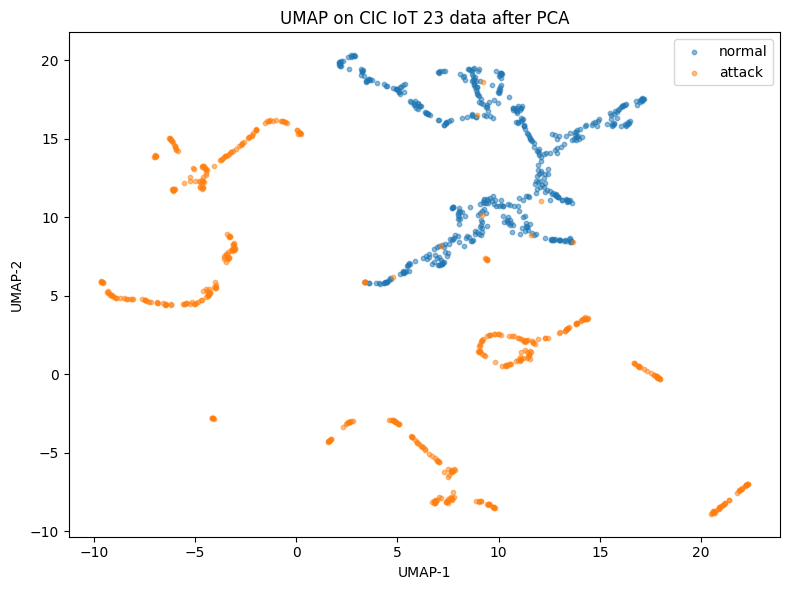

In [6]:
plot_umap(
    prep["X_vis_pca"],
    prep["y_vis"],
    "UMAP on CIC IoT 23 data after PCA"
)


/home/senachioiu/AQA-QDL/AQA_QDL-main/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/senachioiu/AQA-QDL/AQA_QDL-main/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


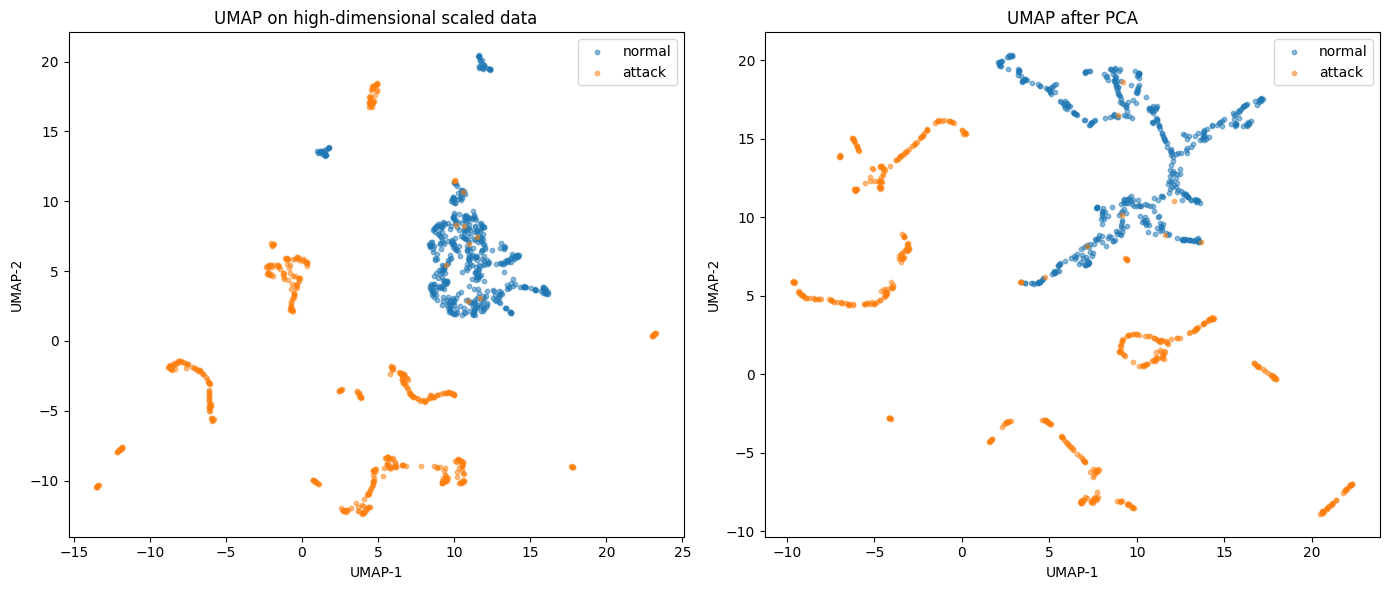

In [7]:
plot_umap_comparison(
    prep["X_vis_scaled"],
    prep["X_vis_pca"],
    prep["y_vis"],
)


Linear classifier on the first 2 principal components
Accuracy: 0.9722
ROC-AUC:  0.9931
              precision    recall  f1-score   support

           0       0.46      1.00      0.63      3315
           1       1.00      0.97      0.99    139148

    accuracy                           0.97    142463
   macro avg       0.73      0.98      0.81    142463
weighted avg       0.99      0.97      0.98    142463



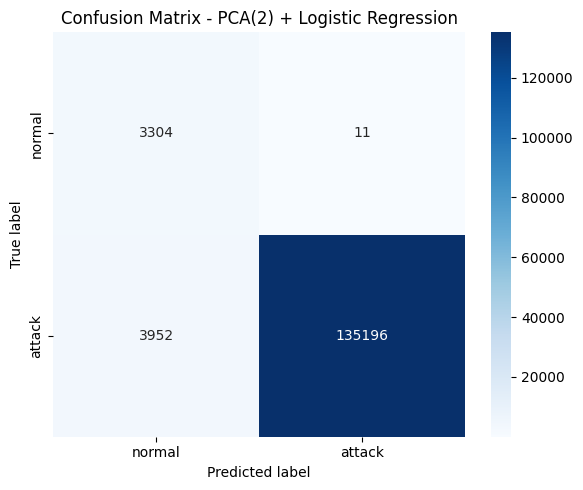

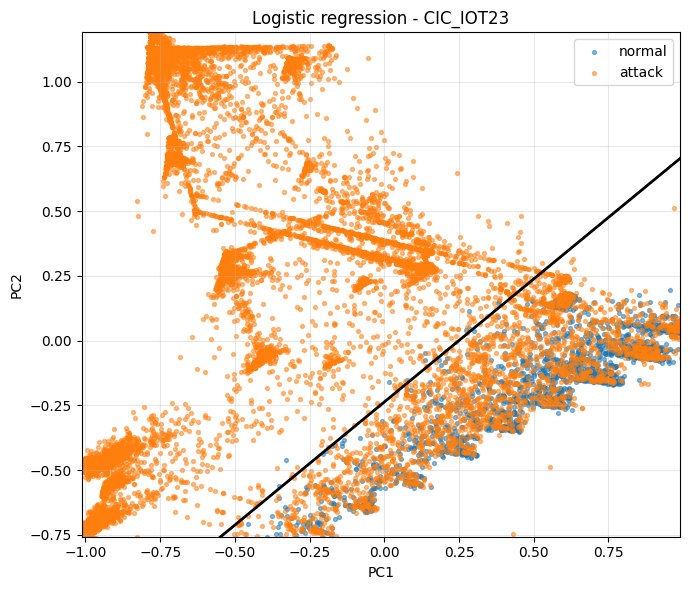

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# first 2 PCA coordinates
X_train_pca2 = X_train[:, :2]
X_test_pca2 = X_test[:, :2]

lin_clf = LogisticRegression(
    max_iter=1000,
    random_state=42,
)

lin_clf.fit(X_train_pca2, y_train)

y_pred_pca2 = lin_clf.predict(X_test_pca2)
y_prob_pca2 = lin_clf.predict_proba(X_test_pca2)[:, 1]

print("Linear classifier on the first 2 principal components")
print(f"Accuracy: {accuracy_score(y_test, y_pred_pca2):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_pca2):.4f}")
print(classification_report(y_test, y_pred_pca2))

cm_lg = confusion_matrix(y_test, y_pred_pca2)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lg,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["normal", "attack"],
    yticklabels=["normal", "attack"],
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - PCA(2) + Logistic Regression")
plt.tight_layout()
plt.show()


# ---------------- decision boundary plot ----------------

plt.figure(figsize=(7, 6))

mask_normal = (y_test == 0)
mask_attack = (y_test == 1)

plt.scatter(
    X_test_pca2[mask_normal, 0],
    X_test_pca2[mask_normal, 1],
    s=8,
    alpha=0.5,
    label="normal",
)

plt.scatter(
    X_test_pca2[mask_attack, 0],
    X_test_pca2[mask_attack, 1],
    s=8,
    alpha=0.5,
    label="attack",
)

xx, yy = np.meshgrid(
    np.linspace(X_test_pca2[:, 0].min(), X_test_pca2[:, 0].max(), 400),
    np.linspace(X_test_pca2[:, 1].min(), X_test_pca2[:, 1].max(), 400),
)
grid = np.c_[xx.ravel(), yy.ravel()]
zz = lin_clf.decision_function(grid).reshape(xx.shape)

plt.contour(xx, yy, zz, levels=[0], colors="black", linewidths=2)

x_lo, x_hi = np.percentile(X_test_pca2[:, 0], [1, 99])
y_lo, y_hi = np.percentile(X_test_pca2[:, 1], [1, 99])
plt.xlim(x_lo, x_hi)
plt.ylim(y_lo, y_hi)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Logistic regression - CIC_IOT23")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()